
## Notebook 3: Supervised Classification — CNN

This notebook blends the Week 3 data fetching notebook (for JRC label
acquisition via GEE) and the Week 3 rollout notebook (for patch extraction,
CNN prediction, and full image rollout). The CNN is built from scratch and
trained on JRC water labels before being rolled out across the full Aral Sea
image for each year.

## Setup
Run this cell first. It imports all required libraries, mounts Google Drive,
and starts the timer used to calculate the environmental cost at the end of
the notebook.

In [1]:
import time #timer for environmental cost
notebook_start = time.time()

import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import os

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import ee
import geemap

from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/aral_sea/'
FIG_DIR  = '/content/drive/MyDrive/aral_sea/figures/'
os.makedirs(FIG_DIR, exist_ok=True)

YEARS          = [2015, 2018, 2021, 2024]
CLASS_NAMES    = ['Open water', 'Brine / shallow', 'Salt flat', 'Desert scrub']
CLASS_COLOURS  = ['#1a6faf', '#7ec8e3', '#f5deb3', '#c8a882']
PIXEL_AREA_KM2 = 0.01
PATCH_SIZE     = 3   # 3x3 patches — same as Week 3 rollout skeleton

Mounted at /content/drive


## Fetch Training Labels from JRC Global Surface Water

Training labels are fetched from the JRC Global Surface Water dataset via GEE.


In [2]:
ee.Authenticate()
ee.Initialize(project='aral-sea-496719')

aoi = ee.Geometry.Rectangle([57.5, 43.0, 61.5, 46.5])

# JRC Global Surface Water — water occurrence (0-100%)
# Pixels with >50% water occurrence classified as water
jrc = ee.Image('JRC/GSW1_4/GlobalSurfaceWater').select('occurrence')
water_mask = jrc.gt(50).rename('water')  # 1 = water, 0 = non-water

# Export JRC water mask to Drive
task = ee.batch.Export.image.toDrive(
    image=water_mask,
    description='jrc_water_mask',
    folder='aral_sea',
    fileNamePrefix='jrc_water_mask',
    region=aoi,
    scale=100,
    crs='EPSG:4326',
    maxPixels=1e9
)
task.start()
print('JRC water mask export started — check GEE Tasks tab')

JRC water mask export started — check GEE Tasks tab


## Load Index Data and JRC Labels

The NDWI, MNDWI and NDVI GeoTIFFs from Notebook 1 are loaded alongside
the JRC water mask. The JRC mask provides binary water/non-water labels
used to train the CNN.

In [3]:
# Load index stacks — same rasterio pattern as Notebook 2
data = {}
for year in YEARS:
    path = f'{DATA_DIR}aral_sea_indices_{year}.tif'
    with rasterio.open(path) as src:
        ndwi  = src.read(1).astype(float)
        mndwi = src.read(2).astype(float)
        ndvi  = src.read(3).astype(float)
    for arr in [ndwi, mndwi, ndvi]:
        arr[arr < -1] = np.nan
    data[year] = np.stack([ndwi, mndwi, ndvi], axis=-1)  # (H, W, 3)
    print(f'{year}: loaded')

H, W, _ = data[2015].shape

# Load JRC water mask
with rasterio.open(f'{DATA_DIR}jrc_water_mask.tif') as src:
    jrc_labels = src.read(1).astype(float)

print(f'JRC labels loaded — shape {jrc_labels.shape}')
print(f'Water pixels: {int(np.sum(jrc_labels == 1))}')
print(f'Non-water pixels: {int(np.sum(jrc_labels == 0))}')

2015: loaded
2018: loaded
2021: loaded
2024: loaded
JRC labels loaded — shape (3916, 4454)
Water pixels: 1606046
Non-water pixels: 15835818


## Extract Training Patches

Patches of size 3×3 are extracted around each labelled pixel, following
the same approach used in the Week 3 rollout skeleton. The patch size
remains 3×3 but with 3 channels (NDWI, MNDWI, NDVI) instead of 21 OLCI
bands.

To avoid memory crashes in Google Colab, a random subsample is used for
training rather than all available pixels.

Water and non-water pixels are sampled equally at 5,000 each to prevent
class imbalance. Without this the CNN learns to predict non-water for
everything, as non-water pixels outnumber water pixels by roughly 10:1
across the Aral Sea region.

In [4]:
import numpy as np
from skimage.transform import resize # Import necessary library for resizing

# Patch extraction — adapted from Week 3 rollout skeleton
# Classes are balanced to avoid the CNN predicting only non-water
# (JRC labels have ~10x more non-water than water pixels)
image = data[2015]
image = np.nan_to_num(image, nan=0.0)

# Get target shape from the image
target_h, target_w, _ = image.shape

# Resize jrc_labels to match the image dimensions
# Use order=0 for nearest-neighbor interpolation to preserve binary labels
# preserve_range=True to maintain 0/1 values, anti_aliasing=False for simple resizing
jrc_labels_resized = resize(jrc_labels, (target_h, target_w), order=0, preserve_range=True, anti_aliasing=False)
jrc_labels_resized = np.round(jrc_labels_resized).astype(int) # Ensure labels are binary integers after resize

# Use the resized labels for extraction
# Get water and non-water pixel positions separately
water_rows,    water_cols    = np.where(jrc_labels_resized == 1)
nonwater_rows, nonwater_cols = np.where(jrc_labels_resized == 0)

# Subsample each class equally — use all water pixels up to 5000,
# then match with same number of non-water pixels
np.random.seed(42)
n_water = min(5000, len(water_rows))
water_idx    = np.random.choice(len(water_rows),    size=n_water, replace=False)
nonwater_idx = np.random.choice(len(nonwater_rows), size=n_water, replace=False)

# Combine and shuffle
sel_rows = np.concatenate([water_rows[water_idx],    nonwater_rows[nonwater_idx]])
sel_cols = np.concatenate([water_cols[water_idx],    nonwater_cols[nonwater_idx]])
shuffle  = np.random.permutation(len(sel_rows))
sel_rows, sel_cols = sel_rows[shuffle], sel_cols[shuffle]

patches = []
labels  = []

for i, j in zip(sel_rows, sel_cols):
    # Skip border pixels
    # The dimensions (image.shape[0]-1, image.shape[1]-1) now correspond to jrc_labels_resized
    if i == 0 or i == image.shape[0]-1: # Use image.shape here as jrc_labels_resized matches it
        continue
    if j == 0 or j == image.shape[1]-1: # Use image.shape here as jrc_labels_resized matches it
        continue
    patch = image[i-1:i+2, j-1:j+2, :]
    patches.append(patch)
    labels.append(int(jrc_labels_resized[i, j])) # Use resized labels for getting label

x_all = np.array(patches)
y_all = np.array(labels)

print(f'Total patches: {x_all.shape}')
print(f'Water={np.sum(y_all==1)}, Non-water={np.sum(y_all==0)}')

Total patches: (9969, 3, 3, 3)
Water=4989, Non-water=4980


## Train / Test Split

Data is split 80% training and 20% testing before the CNN is trained,
so performance can be evaluated on unseen pixels. This is standard practice for supervised ML evaluation.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    x_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print(f'Training patches: {X_train.shape}')
print(f'Test patches:     {X_test.shape}')

Training patches: (7975, 3, 3, 3)
Test patches:     (1994, 3, 3, 3)


## Build and Train CNN

The CNN architecture follows the same structure as the model used in the
Week 2 AI Algorithms skeleton and loaded in the Week 3 rollout notebook.
The input shape is (3, 3, 3) — three channels (NDWI, MNDWI, NDVI) instead
of 21 OLCI bands, and the output is 2 classes (water / non-water) instead
of sea ice / lead.

In [6]:
# CNN model — adapted from Week 2 AI Algorithms skeleton
# CHANGED: input shape (3,3,3) instead of (3,3,21)
# CHANGED: output units=2 (water/non-water) instead of 2 (ice/lead)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3, 3, 3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

# Save model to Drive
model.save(f'{DATA_DIR}cnn_aral_sea.h5')
print('Model saved')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 3, 3, 32)       │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,522 (76.26 KB)

 Trainable params: 19,522 (76.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.6225 - loss: 0.5890 - val_accuracy: 0.6454 - val_loss: 0.5327
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6313 - loss: 0.5414 - val_accuracy: 0.6454 - val_loss: 0.5258
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6317 - loss: 0.5376 - val_accuracy: 0.6140 - val_loss: 0.5251
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6253 - loss: 0.5350 - val_accuracy: 0.6466 - val_loss: 0.5224
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6221 - loss: 0.5322 - val_accuracy: 0.6466 - val_loss: 0.5202
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6251 - loss: 0.5320 - val_accuracy: 0.6479 - val_loss: 0.5195
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6302 - loss: 0.5282 - val_accuracy: 0.6466 - val_loss: 0.5180
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6316 - loss: 0.5272 - val_accuracy: 0.6466 - v

Model saved


## Evaluate on Test Set

The trained CNN is evaluated on the 20% of data we held back during training using a classification
report and confusion matrix — the same evaluation approach used in the Week 4
skeleton. The classification report shows precision, recall and F1 score for
each class, while the confusion matrix shows how many pixels were correctly
and incorrectly classified.

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
=== CNN Classification Report ===
              precision    recall  f1-score   support

   Non-water       0.98      0.29      0.44       996
       Water       0.58      0.99      0.73       998

    accuracy                           0.64      1994
   macro avg       0.78      0.64      0.59      1994
weighted avg       0.78      0.64      0.59      1994



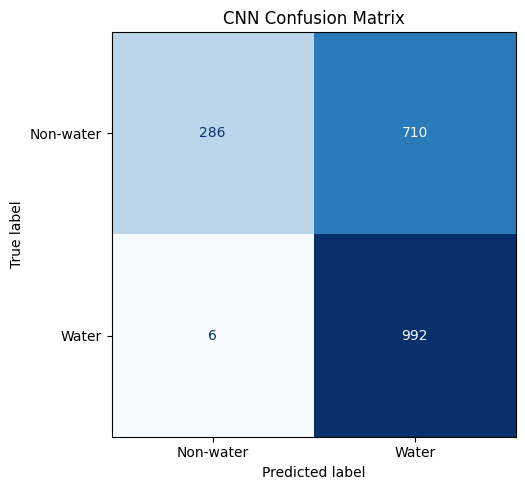

In [7]:
# Predict on test set — kept from Week 3 rollout skeleton
# np.argmax converts probability scores to class predictions (0 or 1)
y_pred = np.argmax(model.predict(X_test, batch_size=256), axis=1)

# Classification report — kept from Week 4 skeleton
# Prints precision, recall and F1 score for each class
print('=== CNN Classification Report ===')
print(classification_report(y_test, y_pred,
      target_names=['Non-water', 'Water']))

# Confusion matrix — kept from Week 4 skeleton
# Shows how many pixels were correctly and incorrectly classified
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Non-water', 'Water'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('CNN Confusion Matrix')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}cnn_confusion_matrix.png', dpi=150)
plt.show()

## Roll Out CNN Across Full Image

The trained CNN is applied to the full Aral Sea image for each year,
following the sliding window rollout approach from the Week 3 skeleton.
To avoid memory crashes in Google Colab, the image is processed one row
at a time rather than all at once. This produces a classification map
for each year showing water and non-water areas.

In [8]:
# Full image rollout — kept from Week 3 rollout skeleton
cnn_maps = {}

for year in YEARS:
    print(f'Rolling out CNN on {year}...')
    image_yr = np.nan_to_num(data[year], nan=0.0)
    H_yr, W_yr, _ = image_yr.shape

    # Extract all patches efficiently using numpy slicing

    patches = np.array([
        image_yr[i-1:i+2, j-1:j+2, :]
        for i in range(1, H_yr - 1)
        for j in range(1, W_yr - 1)
    ])

    # Single predict call
    y_pred  = model.predict(patches, batch_size=2048, verbose=1)
    y_pred1 = np.argmax(y_pred, axis=1)
    cnn_maps[year] = y_pred1.reshape(H_yr - 2, W_yr - 2)

    print(f'  {year}: done — map shape {cnn_maps[year].shape}')

Rolling out CNN on 2015...
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
  2015: done — map shape (782, 890)
Rolling out CNN on 2018...
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
  2018: done — map shape (782, 890)
Rolling out CNN on 2021...
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
  2021: done — map shape (782, 890)
Rolling out CNN on 2024...
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
  2024: done — map shape (782, 890)


## Plot CNN Classification Maps

Classification maps for all four years are plotted side by side,
showing how the water extent has changed between 2015 and 2024.

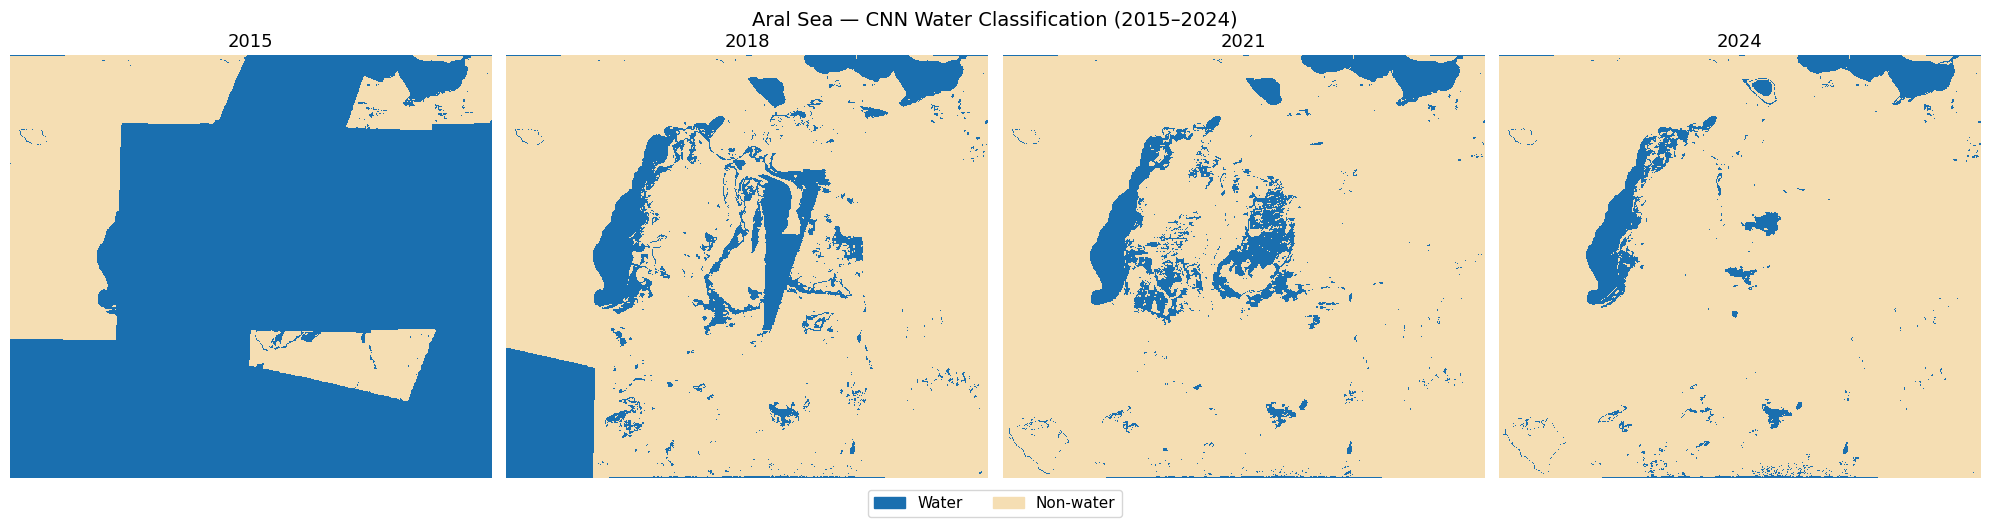

In [9]:
fig, axes = plt.subplots(1, len(YEARS), figsize=(5 * len(YEARS), 5))
cmap = mcolors.ListedColormap(['#f5deb3', '#1a6faf'])  # non-water, water

for ax, year in zip(axes, YEARS):
    ax.imshow(cnn_maps[year], cmap=cmap, vmin=0, vmax=1,
              interpolation='nearest')
    ax.set_title(str(year), fontsize=13)
    ax.axis('off')

patches = [
    mpatches.Patch(color='#1a6faf', label='Water'),
    mpatches.Patch(color='#f5deb3', label='Non-water')
]
fig.legend(handles=patches, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.05), fontsize=11)
plt.suptitle('Aral Sea — CNN Water Classification (2015–2024)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}cnn_classification_maps.png', dpi=150,
            bbox_inches='tight')
plt.show()

## GMM vs CNN Comparison

Water area estimates from the GMM (Notebook 2) and CNN are compared for
each year. Before running this cell, I replaced the placeholder values in
`gmm_water` with the open water km² figures printed at the end of Notebook 2.

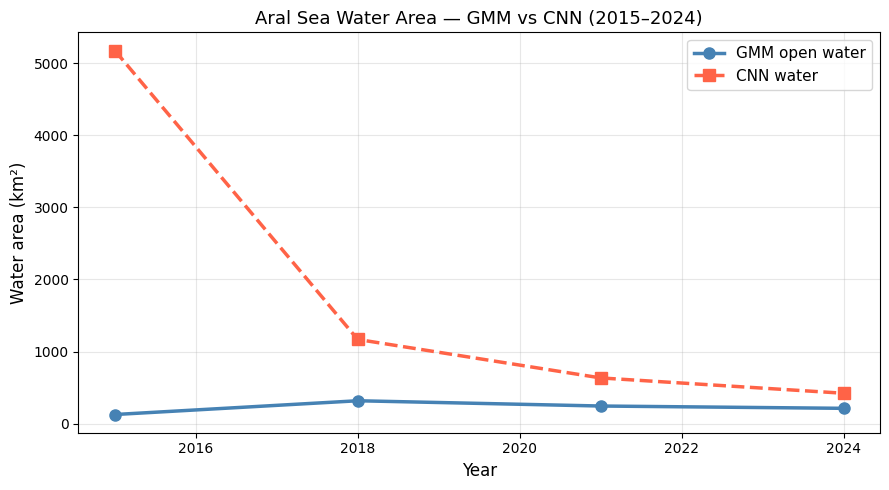


Water area comparison (km²):
Year          GMM        CNN   Difference
----------------------------------------
2015          126       5176         5050
2018          317       1168          851
2021          244        634          390
2024          212        421          209


In [10]:
# CNN water area per year
cnn_water = [np.sum(cnn_maps[y] == 1) * PIXEL_AREA_KM2 for y in YEARS]

# Load GMM water areas from Notebook 2 outputs
# (manually enter open water values printed at the end of Notebook 2)
gmm_water = [126, 317, 244, 212] # replaced with actual values from Notebook 2

# Comparison plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(YEARS, gmm_water, 'o-', color='steelblue', linewidth=2.5,
        markersize=8, label='GMM open water')
ax.plot(YEARS, cnn_water, 's--', color='tomato', linewidth=2.5,
        markersize=8, label='CNN water')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Water area (km²)', fontsize=12)
ax.set_title('Aral Sea Water Area — GMM vs CNN (2015–2024)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}gmm_vs_cnn_comparison.png', dpi=150)
plt.show()

print('\nWater area comparison (km²):')
print(f'{"Year":<6} {"GMM":>10} {"CNN":>10} {"Difference":>12}')
print('-' * 40)
for y, g, c in zip(YEARS, gmm_water, cnn_water):
    print(f'{y:<6} {g:>10.0f} {c:>10.0f} {abs(g-c):>12.0f}')

## GMM vs CNN Classification Map Comparison

The GMM and CNN classification maps are shown side by side for 2024 to
visually illustrate where the two methods agree and disagree on water
extent. Areas of disagreement are discussed in the README.

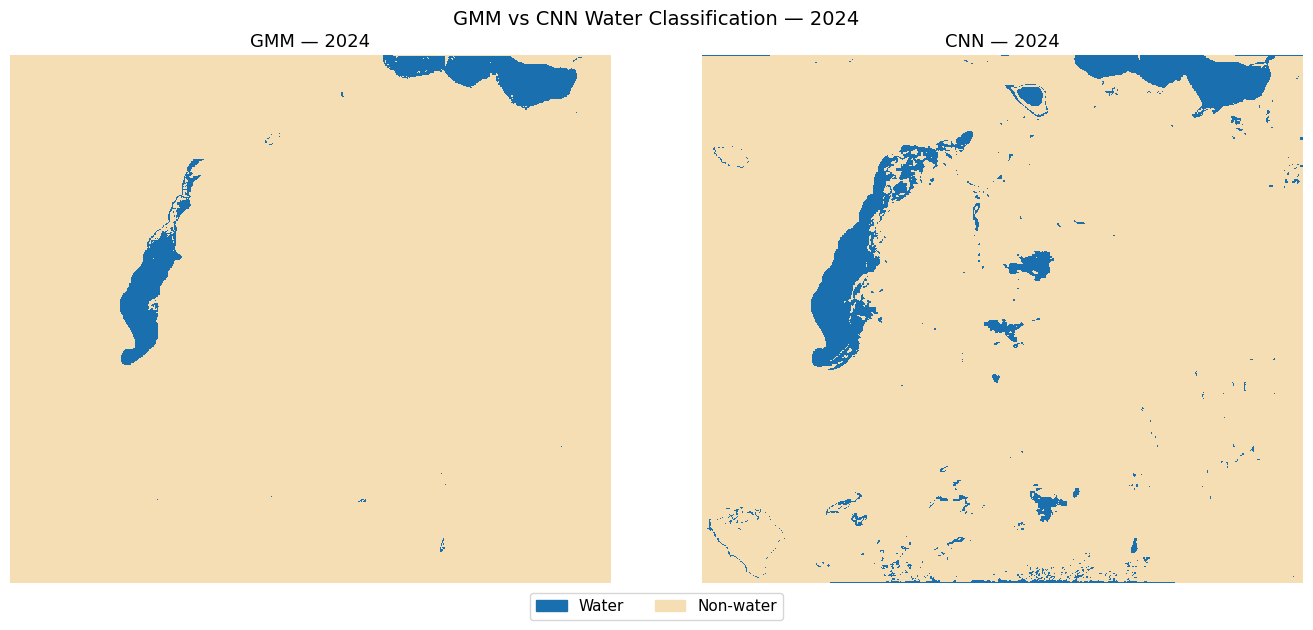

In [11]:
# Load GMM 2024 label map for visual comparison
# Remap GMM clusters to water (1) / non-water (0) for fair comparison
import pickle
with open(f'{DATA_DIR}gmm_outputs.pkl', 'rb') as f:
    gmm_outputs = pickle.load(f)

label_maps       = gmm_outputs['label_maps']
cluster_to_class = gmm_outputs['cluster_to_class']

gmm_2024 = label_maps[2024]
gmm_water_map = np.vectorize(
    lambda x: 1 if (not np.isnan(x) and cluster_to_class.get(int(x)) == 0) else 0
)(gmm_2024)

# Side by side comparison
cmap = mcolors.ListedColormap(['#f5deb3', '#1a6faf'])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.imshow(gmm_water_map, cmap=cmap, vmin=0, vmax=1, interpolation='nearest')
ax1.set_title('GMM — 2024', fontsize=13)
ax1.axis('off')

ax2.imshow(cnn_maps[2024], cmap=cmap, vmin=0, vmax=1, interpolation='nearest')
ax2.set_title('CNN — 2024', fontsize=13)
ax2.axis('off')

patches = [
    mpatches.Patch(color='#1a6faf', label='Water'),
    mpatches.Patch(color='#f5deb3', label='Non-water')
]
fig.legend(handles=patches, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.05), fontsize=11)
plt.suptitle('GMM vs CNN Water Classification — 2024', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}gmm_vs_cnn_map_2024.png', dpi=150, bbox_inches='tight')
plt.show()

## Environmental Cost Comparison

This chart compares the total CO₂e emissions of this project against
common everyday activities to provide context for the computational cost.
The log scale is used due to the large difference in magnitude between
the project emissions and a field survey equivalent.
*The numbers on the chart are slightly different to those on the walkthrough YouTube video as I ran the code again, so the runtime is different*

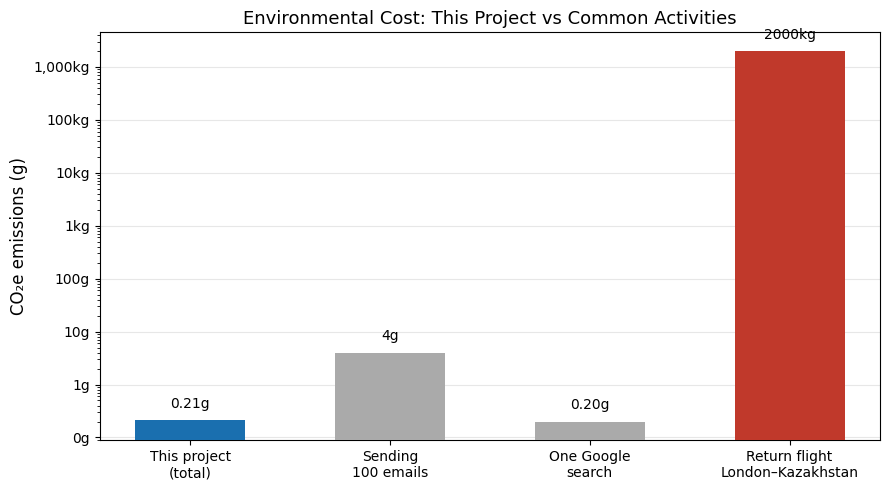

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os

FIG_DIR  = '/content/drive/MyDrive/aral_sea/figures/'
os.makedirs(FIG_DIR, exist_ok=True)

labels = [
    'This project\n(total)',
    'Sending\n100 emails',
    'One Google\nsearch',
    'Return flight\nLondon–Kazakhstan'
]

values = [
    0.2101,
    4,
    0.2,
    2_000_000
]

colours = ['#1a6faf', '#aaaaaa', '#aaaaaa', '#c0392b']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, values, color=colours, width=0.55, zorder=3)
ax.set_yscale('log')
ax.set_ylabel('CO₂e emissions (g)', fontsize=12)
ax.set_title('Environmental Cost: This Project vs Common Activities', fontsize=13)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{x:,.0f}g' if x < 1000 else f'{x/1000:,.0f}kg'
))
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

for bar, val in zip(bars, values):
    label = f'{val:.2f}g' if val < 1 else (f'{val:.0f}g' if val < 1000 else f'{val/1000:.0f}kg')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.5,
            label, ha='center', va='bottom', fontsize=10, fontweight='500')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}environmental_cost_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Environmental Cost

Runtime is recorded automatically for Notebook 3 and used to estimate energy
consumption. The Notebook 1 and Notebook 2 runtimes are entered manually —
replace the placeholder values with the figures printed at the end of each
notebook before running this cell. All three are then combined to produce the
total project environmental cost.

Assumptions: 20W CPU, UK grid carbon intensity of 0.233 kg CO2/kWh,
electricity cost of £0.30/kWh.

In [13]:
runtime_mins = (time.time() - notebook_start) / 60
energy_kwh   = 0.020 * (runtime_mins / 60)
co2_kg       = energy_kwh * 0.233
cost_gbp     = energy_kwh * 0.30

print('=== Notebook 3 Environmental Cost ===')
print(f'Runtime:  {runtime_mins:.2f} min')
print(f'Energy:   {energy_kwh * 1000:.4f} Wh')
print(f'CO2e:     {co2_kg * 1000:.4f} g')
print(f'Cost:     £{cost_gbp:.4f}')

# Total project summary — fill in Notebook 1 and 2 runtimes below
nb1_runtime = 0.6122053345044454 # replace with runtime printed at end of Notebook 1
nb2_runtime = 0.77  # replace with runtime printed at end of Notebook 2
total_mins  = nb1_runtime + nb2_runtime + runtime_mins
total_energy = 0.020 * (total_mins / 60)
total_co2    = total_energy * 0.233
total_cost   = total_energy * 0.30

print('\n=== Total Project Environmental Cost ===')
print(f'Notebook 1: {nb1_runtime:.2f} min')
print(f'Notebook 2: {nb2_runtime:.2f} min')
print(f'Notebook 3: {runtime_mins:.2f} min')
print(f'Total runtime:  {total_mins:.2f} min')
print(f'Total energy:   {total_energy * 1000:.4f} Wh')
print(f'Total CO2e:     {total_co2 * 1000:.4f} g')
print(f'Total cost:     £{total_cost:.4f}')

=== Notebook 3 Environmental Cost ===
Runtime:  1.32 min
Energy:   0.4408 Wh
CO2e:     0.1027 g
Cost:     £0.0001

=== Total Project Environmental Cost ===
Notebook 1: 0.61 min
Notebook 2: 0.77 min
Notebook 3: 1.32 min
Total runtime:  2.70 min
Total energy:   0.9015 Wh
Total CO2e:     0.2101 g
Total cost:     £0.0003
